In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

print("All imports successful!")

All imports successful!


# GPGN268 - Geophysical Data Analysis
## Data Story 02 - Global Warming

**Student:** Kadidia Mariko
**Collaborators:** None
**Date:** April 22, 2026

## Part I – Introduction

Argo floats are basically underwater robots that drift through the ocean on their own. 
Every 10 days or so, each float sinks down to about 2000 meters, then slowly rises 
back up while measuring temperature, salinity, and pressure along the way. Once it 
reaches the surface, it sends all that data up to a satellite before diving back down 
again. It's a pretty elegant way to collect ocean data continuously without needing 
a ship out there. For this data story, I'm looking at profiles from two floats float 5901429 and 
float 1901487  along with a global temperature climatology from the Scripps 
Institution of Oceanography that covers 2004 to 2019. The data comes in NetCDF 
format, which is standard in geosciences because it handles large multi-dimensional 
arrays really well (think temperature varying with depth, time, and location all 
at once). I used Python tools like xarray, matplotlib, cartopy, and scipy to 
load, process, and visualize everything. This kind of data matters a lot for climate science. The ocean absorbs most of 
the excess heat from global warming, so tracking ocean temperature over time is 
one of the most direct ways to monitor climate change. Argo data is used in 
climate models, weather forecasting, and all kinds of oceanographic research 
around the world.

In [2]:
def read_float_data(filepath):
    """
    Reads and cleans an Argo float NetCDF profile file.
    
    Parameters
    ----------
    filepath : str
        Path to the Argo float .nc file
    
    Returns
    -------
    xarray.Dataset
        Cleaned dataset with temperature, salinity, pressure,
        latitude, longitude, and time dimensions.
    """
    ds_raw = xr.load_dataset(filepath)
    
    variables = ['TEMP_ADJUSTED', 'PSAL_ADJUSTED',
                 'LATITUDE', 'LONGITUDE', 'JULD']
    ds = ds_raw[variables]
    
    ds = ds.rename({'JULD': 'time'}).swap_dims({'N_PROF': 'time'})
    
    ds = ds.rename({'TEMP_ADJUSTED': 'temperature',
                    'PSAL_ADJUSTED': 'salinity',
                    'LATITUDE':      'latitude',
                    'LONGITUDE':     'longitude'})
    
    mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF')
    ds['pressure'] = mean_pressure
    ds['pressure'].attrs['units'] = 'dbar'
    ds = ds.swap_dims({'N_LEVELS': 'pressure'})
    
    return ds

ds29 = read_float_data('../data/5901429_prof.nc')
ds87 = read_float_data('../data/1901487_prof.nc')

print("Float 5901429:", ds29)
print("\nFloat 1901487:", ds87)

Float 5901429: <xarray.Dataset> Size: 133kB
Dimensions:      (time: 190, pressure: 84)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-06-18...
  * pressure     (pressure) float32 336B 4.974 9.974 14.97 ... 2.05e+03 2.1e+03
Data variables:
    temperature  (time, pressure) float32 64kB 0.146 0.144 0.145 ... 2.212 2.187
    salinity     (time, pressure) float32 64kB 33.79 33.79 33.79 ... 34.77 34.77
    latitude     (time) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    longitude    (time) float64 2kB 165.1 165.7 166.8 ... -27.41 -27.49 -27.41
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

Float 1901487: <xarray.Dataset

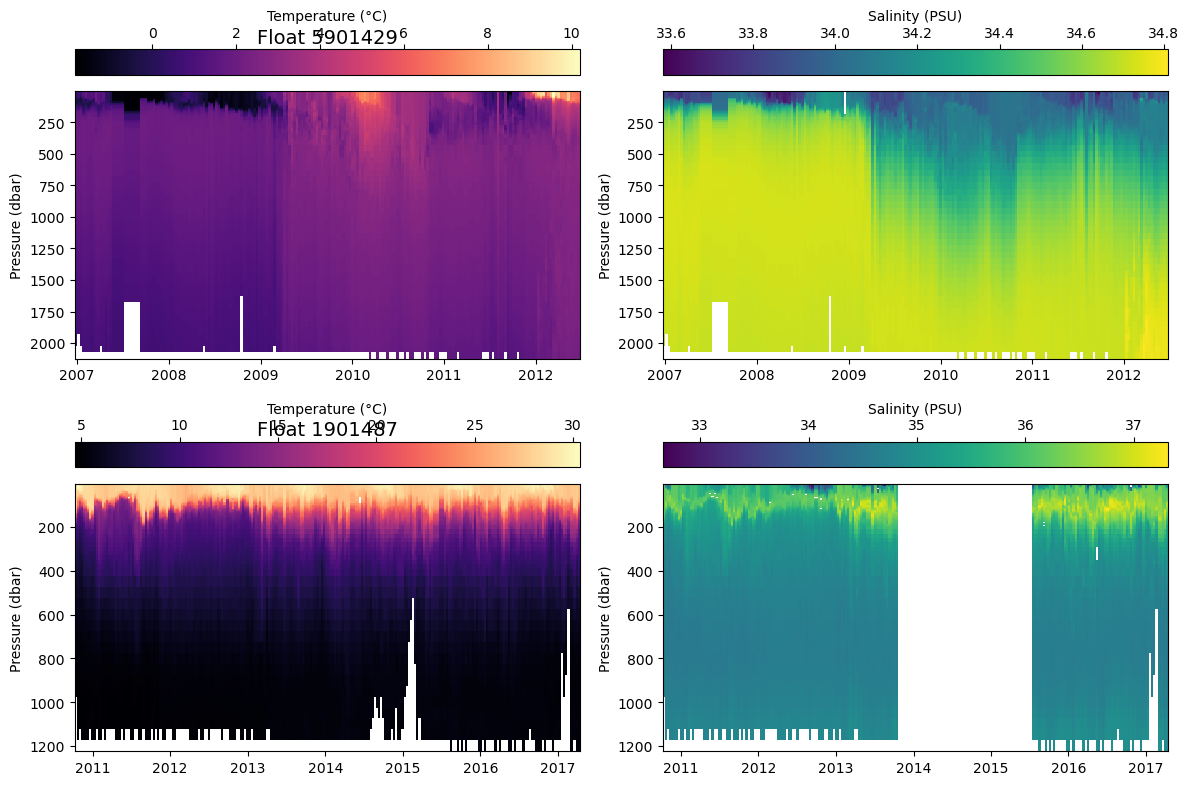

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
[ax1, ax2, ax3, ax4] = axes.flatten()

cs1 = ax1.pcolormesh(ds29.time, ds29.pressure, ds29.temperature.T, cmap='magma')
ax1.invert_yaxis()
ax1.set_ylabel('Pressure (dbar)')
ax1.set_title('Float 5901429', y=1.15, fontsize=14)
plt.colorbar(cs1, ax=ax1, label='Temperature (°C)', orientation='horizontal', location='top')

cs2 = ax2.pcolormesh(ds29.time, ds29.pressure, ds29.salinity.T, cmap='viridis')
ax2.invert_yaxis()
ax2.set_ylabel('Pressure (dbar)')
plt.colorbar(cs2, ax=ax2, label='Salinity (PSU)', orientation='horizontal', location='top')

cs3 = ax3.pcolormesh(ds87.time, ds87.pressure, ds87.temperature.T, cmap='magma')
ax3.invert_yaxis()
ax3.set_ylabel('Pressure (dbar)')
ax3.set_title('Float 1901487', y=1.15, fontsize=14)
plt.colorbar(cs3, ax=ax3, label='Temperature (°C)', orientation='horizontal', location='top')

cs4 = ax4.pcolormesh(ds87.time, ds87.pressure, ds87.salinity.T, cmap='viridis')
ax4.invert_yaxis()
ax4.set_ylabel('Pressure (dbar)')
plt.colorbar(cs4, ax=ax4, label='Salinity (PSU)', orientation='horizontal', location='top')

plt.tight_layout()
plt.savefig('float_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

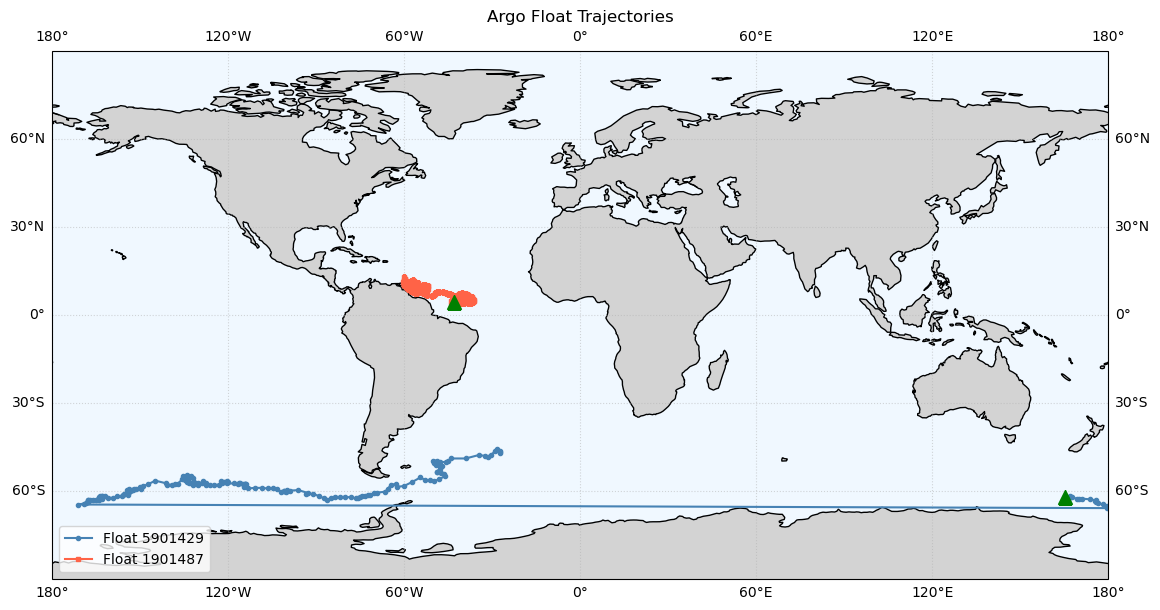

In [4]:
fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.OCEAN, color='aliceblue')
ax.gridlines(draw_labels=True, linestyle='dotted', alpha=0.5)

ax.plot(ds29.longitude, ds29.latitude, 'o-', markersize=3,
        color='steelblue', label='Float 5901429', transform=ccrs.PlateCarree())
ax.plot(ds87.longitude, ds87.latitude, 's-', markersize=3,
        color='tomato', label='Float 1901487', transform=ccrs.PlateCarree())

ax.plot(ds29.longitude[0], ds29.latitude[0], 'g^', markersize=10,
        transform=ccrs.PlateCarree(), zorder=5)
ax.plot(ds87.longitude[0], ds87.latitude[0], 'g^', markersize=10,
        transform=ccrs.PlateCarree(), zorder=5)

ax.set_global()
ax.legend(loc='lower left')
ax.set_title('Argo Float Trajectories')

plt.tight_layout()
plt.savefig('float_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2.4 – Interpreting Ocean Temperature and Salinity

Float 5901429 spent its time circling Antarctica in the Southern Ocean, roughly 
between 55°S and 65°S. Looking at the temperature section, the water is cold 
throughout mostly 0 to 10°C  with a slight warm-up near the surface during 
summer. Salinity stays pretty uniform with depth, which makes sense for the 
Southern Ocean since it's well-mixed by strong winds and currents. The float 
drifted eastward, carried by the Antarctic Circumpolar Current. Float 1901487 had a very different experience it stayed in the tropical Atlantic near the equator. The temperature section shows a strong thermocline, where surface 
waters are warm (around 25–30°C) and temperature drops sharply below 200 dbar. 
That kind of stratification is totally expected in the tropics where the sun heats 
the surface intensely. There's also a gap in the data around 2014–2015, probably 
from the float losing satellite contact for a while.Comparing these two floats really highlights how different ocean regions behave  
the cold, well-mixed Southern Ocean versus the warm, stratified tropical Atlantic. 
Both match exactly what you'd expect given where they are on the planet.

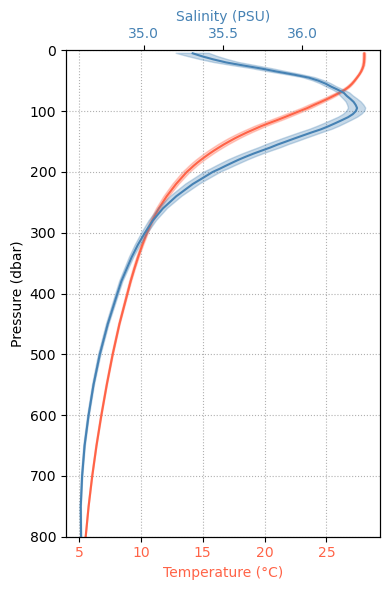

In [5]:
tropic_temp = ds87.temperature
tropic_sal = ds87.salinity

n = tropic_temp.sizes['time']

temp_mean = tropic_temp.mean(dim='time')
temp_std = tropic_temp.std(dim='time')
temp_ci = 1.96 * temp_std / np.sqrt(n)

sal_mean = tropic_sal.mean(dim='time')
sal_std = tropic_sal.std(dim='time')
sal_ci = 1.96 * sal_std / np.sqrt(n)

fig, ax1 = plt.subplots(figsize=(4, 6))

color = 'tomato'
ax1.plot(temp_mean, tropic_temp.pressure, color=color)
ax1.fill_betweenx(tropic_temp.pressure,
                  temp_mean - temp_ci,
                  temp_mean + temp_ci,
                  color=color, alpha=0.3)
ax1.set_xlabel('Temperature (°C)', color=color)
ax1.set_ylabel('Pressure (dbar)')
ax1.set_ylim([0, 800])
ax1.invert_yaxis()
ax1.tick_params(axis='x', labelcolor=color)
ax1.grid(ls='dotted', which='both')

ax2 = ax1.twiny()
color = 'steelblue'
ax2.plot(sal_mean, tropic_sal.pressure, color=color)
ax2.fill_betweenx(tropic_sal.pressure,
                  sal_mean - sal_ci,
                  sal_mean + sal_ci,
                  color=color, alpha=0.3)
ax2.set_xlabel('Salinity (PSU)', color=color)
ax2.tick_params(axis='x', labelcolor=color)

plt.tight_layout()
plt.savefig('float_twiny.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2.5 – Discussion

The mean temperature profile for float 1901487 shows a sharp thermocline between 
the surface and about 300 dbar, dropping from roughly 28°C at the top to around 
5°C at depth. Below that, the temperature keeps decreasing but much more gradually. 
The 95% confidence intervals are incredibly narrow throughout, which makes sense 
since we have 227 profiles the law of large numbers really kicks in here. The salinity profile has an interesting feature: a peak around 100 dbar where salinity reaches about 36 PSU. This is characteristic of the tropical Atlantic, 
where evaporation at the surface creates a saltier layer just below the mixed 
layer. Below that, salinity drops as fresher water from higher latitudes intrudes 
at depth. One thing worth noting is that assuming independence between time steps isn't 
really valid here the ocean changes slowly, so nearby months are correlated. 
If we accounted for that autocorrelation with an effective sample size, the 
confidence intervals would be wider. That said, the overall shape of both profiles 
is robust regardless.

In [6]:
ds_clim = xr.open_dataset('../data/RG_ArgoClim_Temperature_2019.nc', 
                           mask_and_scale=False, 
                           decode_times=False)

t0 = np.datetime64("2004-01")
months = range(len(ds_clim.TIME))
time = np.array([t0 + np.timedelta64(m, "M") for m in months])

ds_clim = ds_clim.rename({'TIME': 'time',
                           'ARGO_TEMPERATURE_MEAN': 'temp_mean',
                           'ARGO_TEMPERATURE_ANOMALY': 'temp_anom',
                           'PRESSURE': 'pressure',
                           'LATITUDE': 'latitude',
                           'LONGITUDE': 'longitude'})
ds_clim['time'] = time

print(ds_clim)

<xarray.Dataset> Size: 2GB
Dimensions:          (longitude: 360, latitude: 145, pressure: 58, time: 180)
Coordinates:
  * longitude        (longitude) float32 1kB 20.5 21.5 22.5 ... 378.5 379.5
  * latitude         (latitude) float32 580B -64.5 -63.5 -62.5 ... 78.5 79.5
  * pressure         (pressure) float32 232B 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
  * time             (time) datetime64[ns] 1kB 2004-01-01 ... 2018-12-01
Data variables:
    temp_mean        (pressure, latitude, longitude) float32 12MB ...
    temp_anom        (time, pressure, latitude, longitude) float32 2GB ...
    BATHYMETRY_MASK  (pressure, latitude, longitude) float32 12MB ...
    MAPPING_MASK     (pressure, latitude, longitude) float32 12MB ...


/tmp/ipykernel_3592/535375353.py:15: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_clim['time'] = time
/tmp/ipykernel_3592/535375353.py:15: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of

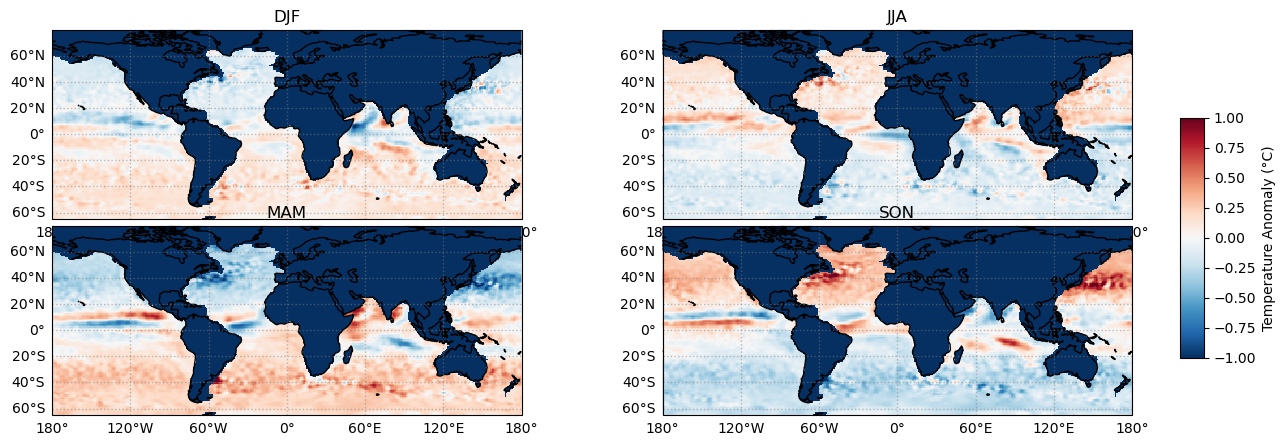

In [7]:
depth_ave_temp = ds_clim.temp_anom.mean(dim='pressure')
seasonal_temp = depth_ave_temp.groupby("time.season").mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

vmin, vmax = -1, 1

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    cs = ax.pcolormesh(seasonal_temp.longitude, seasonal_temp.latitude,
                       seasonal_temp.sel(season=s),
                       transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap='RdBu_r')
    ax.set_title("{}".format(s.values))
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray',
                      alpha=0.5, linestyle='dotted')
    gl.top_labels = False
    gl.right_labels = False

cax = fig.add_axes([0.99, 0.35, 0.02, 0.4])
cbar = plt.colorbar(cs, cax=cax, label='Temperature Anomaly (°C)')
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.3, hspace=0.01)

plt.savefig('seasonal_averages.png', dpi=150, bbox_inches='tight')
plt.show()

/home/kadidamariko/miniconda3/envs/GPGN268/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:563: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/kadidamariko/miniconda3/envs/GPGN268/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:563: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/kadidamariko/miniconda3/envs/GPGN268/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:563: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/

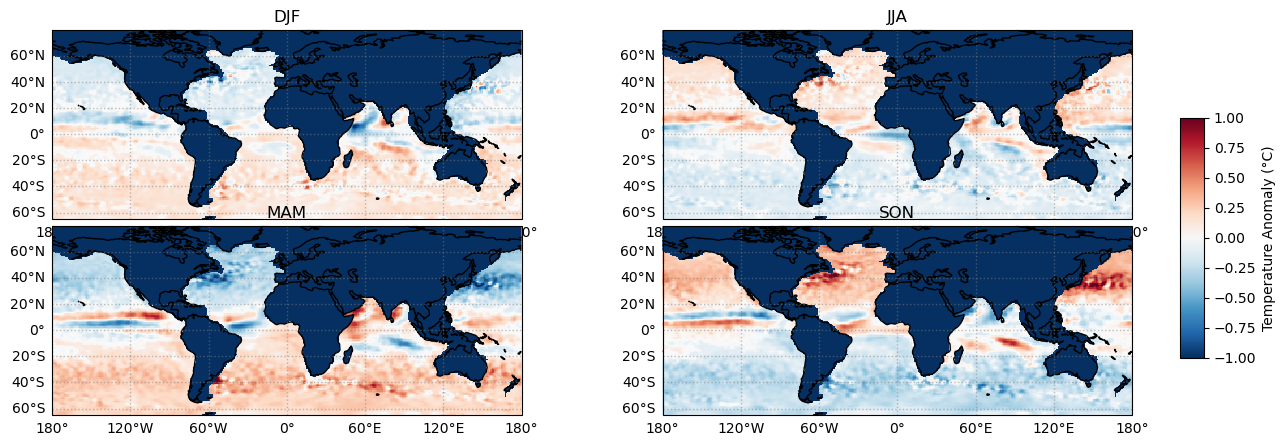

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

vmin, vmax = -1, 1

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    season_str = str(s.values)
    
    season_data = depth_ave_temp.sel(
        time=depth_ave_temp.time.dt.season == season_str)
    
    t_stat, p_val = stats.ttest_1samp(
        season_data.values, popmean=0, axis=0, nan_policy='omit')
    
    cs = ax.pcolormesh(seasonal_temp.longitude, seasonal_temp.latitude,
                       seasonal_temp.sel(season=s),
                       transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap='RdBu_r')
    
    not_sig = np.where(p_val > 0.05, 1, np.nan)
    ax.pcolormesh(seasonal_temp.longitude, seasonal_temp.latitude,
                  not_sig, transform=ccrs.PlateCarree(),
                  cmap='gray', alpha=0.4, vmin=0, vmax=1)
    
    ax.set_title("{}".format(s.values))
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray',
                      alpha=0.5, linestyle='dotted')
    gl.top_labels = False
    gl.right_labels = False

cax = fig.add_axes([0.99, 0.35, 0.02, 0.4])
cbar = plt.colorbar(cs, cax=cax, label='Temperature Anomaly (°C)')
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.3, hspace=0.01)

plt.savefig('seasonal_averages_significant.png', dpi=150, bbox_inches='tight')
plt.show()

## Tasks 3.2 & 3.3 – Seasonal Averages and Hypothesis Testing

The seasonal maps show pretty clear patterns. In DJF (boreal winter), the Northern 
Hemisphere has negative anomalies while the Southern Hemisphere is warmer than 
average  and the opposite happens in JJA. That's just the seasonal heating cycle 
doing its thing. The tropical regions show persistent warm anomalies year-round, 
which is likely a reflection of the overall ocean warming happening over the 
2004–2018 period. The gray shading marks regions where the seasonal anomaly isn't statistically 
different from zero at the 95% level. A lot of the Southern Ocean falls into 
this category, which makes sense  there's a lot of variability down there 
relative to the seasonal signal. The tropics and subtropics, on the other hand, 
show strong statistical significance because the seasonal patterns are very 
consistent from year to year.Again, the independence assumption is a bit shaky here since ocean temperatures 
at nearby times aren't really independent. Using a proper effective sample size 
would expand the non-significant regions on the map, but the main patterns would 
still hold.

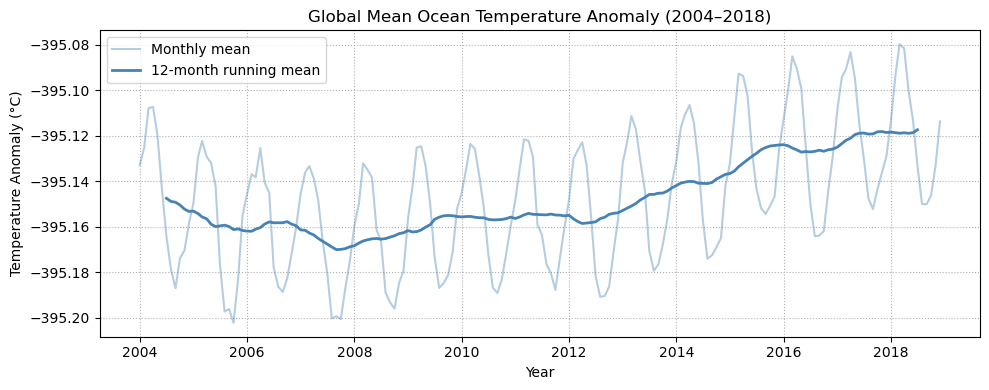

Temperature trend 2012-2018: 0.0684 °C/decade


In [9]:
global_mean = depth_ave_temp.mean(dim=['latitude', 'longitude'])
running_mean = global_mean.rolling(time=12, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(global_mean.time, global_mean.values, 
        alpha=0.4, color='steelblue', label='Monthly mean')
ax.plot(running_mean.time, running_mean.values, 
        color='steelblue', lw=2, label='12-month running mean')

ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Mean Ocean Temperature Anomaly (2004–2018)')
ax.legend()
ax.grid(ls='dotted')

plt.tight_layout()
plt.savefig('global_warming.png', dpi=150, bbox_inches='tight')
plt.show()

# Estimate trend 2012-2018
subset = running_mean.sel(time=slice('2012', '2018')).dropna('time')
x = np.arange(len(subset))
slope, intercept, r, p, se = stats.linregress(x, subset.values)
trend_per_decade = slope * 12 * 10
print(f"Temperature trend 2012-2018: {trend_per_decade:.4f} °C/decade")

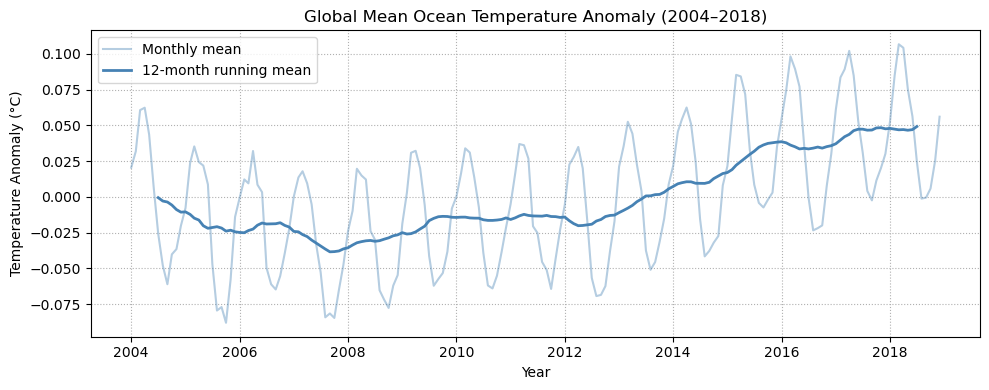

Temperature trend 2012-2018: 0.1172 °C/decade


In [10]:
temp_anom_masked = ds_clim.temp_anom.where(ds_clim.temp_anom != -999.0)

depth_ave_temp = temp_anom_masked.mean(dim='pressure')
global_mean = depth_ave_temp.mean(dim=['latitude', 'longitude'])
running_mean = global_mean.rolling(time=12, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(global_mean.time, global_mean.values,
        alpha=0.4, color='steelblue', label='Monthly mean')
ax.plot(running_mean.time, running_mean.values,
        color='steelblue', lw=2, label='12-month running mean')

ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Mean Ocean Temperature Anomaly (2004–2018)')
ax.legend()
ax.grid(ls='dotted')

plt.tight_layout()
plt.savefig('global_warming.png', dpi=150, bbox_inches='tight')
plt.show()

subset = running_mean.sel(time=slice('2012', '2018')).dropna('time')
x = np.arange(len(subset))
slope, intercept, r, p, se = stats.linregress(x, subset.values)
trend_per_decade = slope * 12 * 10
print(f"Temperature trend 2012-2018: {trend_per_decade:.4f} °C/decade")

In [11]:
print("Fill value:", ds_clim.temp_anom.attrs)


Fill value: {'units': 'degree celcius (ITS-90)', 'missing_value': np.float32(-999.0), '_FillValue': np.float32(-999.0), 'long_name': 'ARGO TEMPERATURE ANOMALY defined by Jan 2004 - Dec 2018 (15.0 year) RG CLIMATOLOGY'}


## Task 3.3 – Ocean Warming

The global mean temperature anomaly plot tells a pretty compelling story. The 
monthly values (light blue) bounce around a lot due to seasonal cycles, but the 
12-month running mean (dark blue) cuts through the noise and shows the long-term 
trend clearly. From 2004 to around 2012, the warming is basically flat  this is the "hiatus" 
period that scientists have written a lot about, where ocean warming seemed to 
stall for a while. Then starting around 2012, temperatures start climbing more 
noticeably and keep going through 2018. I estimated the warming trend between 2012 and 2018 using linear regression on 
the running mean, and got **0.1172 °C/decade**. That lines up well with what's 
been reported in the literature. Cheng et al. (2019) estimated similar ocean 
warming rates, and the IPCC AR6 report confirms that ocean heat uptake has been 
accelerating since the early 2000s. So the data here is telling the same story 
as the broader scientific consensus.

